In [1]:
from diffrax import diffeqsolve, ODETerm,VirtualBrownianTree,MultiTerm,ControlTerm
from jax.scipy.stats import norm, poisson
import diffrax
import jax.numpy as jnp
import jax
import lineax as lx
import matplotlib.pyplot as plt



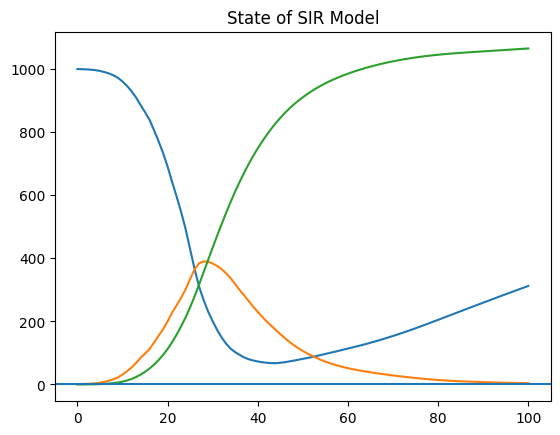

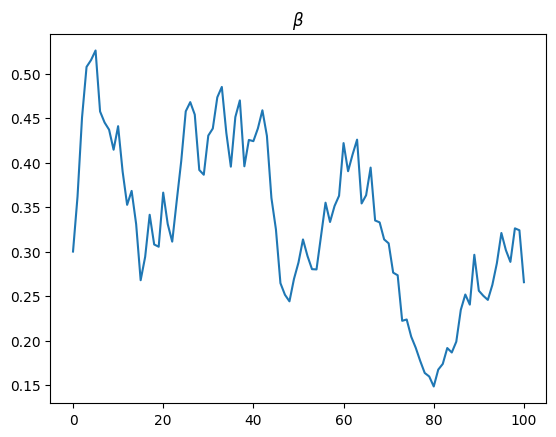

In [2]:
import jax.random as jr
from diffrax import (
    diffeqsolve,
    ControlTerm,
    ReversibleHeun,
    MultiTerm,
    ODETerm,
    SaveAt,
    VirtualBrownianTree,
    PIDController,
)


def drift(t, y, args):
    gamma, xi, lam, mu, sig = args

    S, I, R, log_beta = y

    S = jnp.maximum(S, 0.0)
    I = jnp.maximum(I, 0.0)
    R = jnp.maximum(R, 0.0)

    N = S + I + R

    beta = jnp.exp(log_beta)

    dS = -beta * S * I / N + xi * R
    dI = beta * S * I / N - gamma * I
    dR = gamma * I
    dbeta = -lam * (log_beta - mu)

    return jnp.array([dS, dI, dR, dbeta])


def diffusion(t, y, args):
    gamma, xi, lam, mu, sig = args

    noise_scales = jnp.array([0, 0, 0, sig])

    return lx.DiagonalLinearOperator(noise_scales)


days = 100
delta_t = 1.0
ts = jnp.arange(0.0, days + delta_t, delta_t)
x0 = jnp.array([1000.0, 1.0, 0.0, jnp.log(0.3)])
theta = jnp.array(
    [0.1, 1 / 180, 1 / 35, jnp.log(0.3), 0.1]
)
rng_key = jr.PRNGKey(10)


def model(x0, key, ts, params):

    brownian_motion = VirtualBrownianTree(ts[0], ts[-1], tol=1e-3, shape=(4,), key=key)
    terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, brownian_motion))
    solver = ReversibleHeun()
    saveat = SaveAt(ts=ts)
    controller = PIDController(rtol=1e-3, atol=1e-3)

    sol = diffeqsolve(
        terms,
        solver,
        ts[0],
        ts[-1],
        dt0=0.01,
        y0=x0,
        saveat=saveat,
        args=params,
        stepsize_controller=controller,
        max_steps=100_000,
        throw=False,
    )

    return sol.ys, sol.result


full_state, _ = model(x0, rng_key, ts, theta)

plt.title("State of SIR Model")
plt.plot(ts, full_state[:, 0:3])
plt.axhline(y=0.0)
plt.show()

plt.title("$\\beta$")
plt.plot(ts, jnp.exp(full_state[:, -1]))
plt.show()

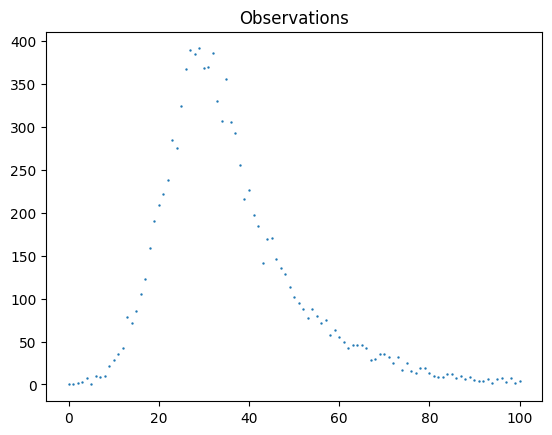

In [3]:
noise_key,rng_key = jax.random.split(rng_key)

observations = jax.random.poisson(noise_key, full_state[:,1])

plt.title("Observations")
plt.scatter(ts, observations,s = 0.5)
plt.show()

In [4]:
def log_likelihood(params, x0, key, ts, observations, N):
    keys = jax.random.split(key, N)
    states, results = jax.vmap(model, in_axes=(None, 0, None, None))(
        x0, keys, ts, params
    )

    lambda_rate = jnp.where(states[..., 1] > 1e-5, states[..., 1], 1e-5)
    log_probs = jax.scipy.stats.poisson.logpmf(observations, lambda_rate)

    total_log_likes = jnp.sum(log_probs, axis=1)

    return jnp.mean(total_log_likes)


num_models = jnp.array([100, 1_000, 10_000, 100_000])

ll_key, rng_key = jax.random.split(rng_key, 2)

log_likelihood_values = []
for model_count in num_models:
    ll_key, rng_key = jax.random.split(rng_key, 2)
    log_likelihood_values.append(
        log_likelihood(theta, x0, ll_key, ts, observations, model_count)
    )

    print(model_count)


100
1000
10000
100000


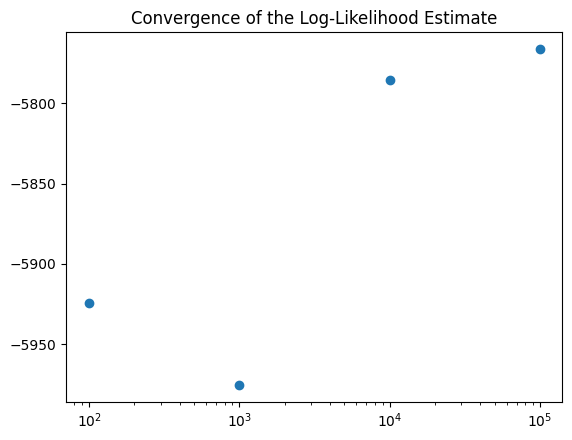

In [5]:
log_likelihood_values = jnp.array(log_likelihood_values)

plt.title('Convergence of the Log-Likelihood Estimate')
plt.scatter(num_models,log_likelihood_values)
plt.xscale('log')
plt.show()

In [6]:
num_models = 100
ll_key, rng_key = jax.random.split(rng_key, 2)

grad_fn = jax.value_and_grad(
    lambda theta, ll_key: log_likelihood(
        theta, x0, ll_key, ts, observations, num_models
    ),
    argnums=0
)

jitted_grad_fn = jax.jit(grad_fn)

value, grad = jitted_grad_fn(theta, ll_key)
print(f"Log-Likelihood: {value}, gradient: {grad}")

Log-Likelihood: -5620.18603515625, gradient: [-53066.414 -38306.633  26990.582   5917.713 -34347.5  ]
